In [1]:
import pickle
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scanpy as sc
from scipy.stats import norm

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.calibration import bh_fdr_reject
from MixedEffectsModeling.PerSamplePathwayAnalysis.pathway_convergence import (
    load_symbol_vocab, overlap_enrichment, pairwise_overlap,
)

ZDIR = config.ZSCORES_MIXED_DIR
PCDIR = config.PATHWAY_CONV_DIR
PFDIR = config.PATHWAY_CONV_FIG_DIR
PCDIR.mkdir(parents=True, exist_ok=True)
PFDIR.mkdir(parents=True, exist_ok=True)
PP = config.PATHWAY_CONV_PARAMS

universe_syms, sym2idx, col2sym = load_symbol_vocab(None)  # phenotype-independent, for gene-level naming


def overlap_stats(masks, n_perm=200, seed=42):
    e = overlap_enrichment(masks, n_perm=n_perm, seed=seed)  # obs_median = median pairwise Jaccard
    jacc, _ = pairwise_overlap(masks)
    e['nonzero_pair_frac'] = float((jacc > 0).mean())
    e['n_sig_median'] = float(np.median(masks.sum(axis=1)))
    return e

CROSS_PATH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'cross_study_replication.csv'

In [2]:
from MixedEffectsModeling.PerSamplePathwayAnalysis.pathway_convergence import q_tag

QS = [0.05, 0.10, 0.15, 0.20, 0.25]


def recurring_items(mask, names, study, level, q):
    n_pat = mask.shape[0]
    counts = mask.sum(axis=0)
    idx = np.where(counts > 0)[0]
    return pd.DataFrame({
        'study_dir': study, 'level': level, 'q': q,
        'item': [names[i] for i in idx], 'n_patients_sig': counts[idx], 'n_pat': n_pat,
        'rate': counts[idx] / n_pat,
    }).sort_values('n_patients_sig', ascending=False)


SWEEP_PATH = PCDIR / 'gene_pathway_reoccurrence_sweep.csv'
DETAIL_PATH = PCDIR / 'gene_pathway_reoccurrence_detail.csv'

sweep = pd.read_csv(SWEEP_PATH) if SWEEP_PATH.exists() else None
if sweep is not None and 'ovc_median' in sweep.columns:
    sweep = sweep.drop(columns='ovc_median')  # dropped: non-intuitive, Jaccard alone is the headline metric
detail = pd.read_csv(DETAIL_PATH) if DETAIL_PATH.exists() else None

if sweep is None or detail is None:
    sweep_rows, detail_rows = [], []
    for pdir in sorted(d for d in PCDIR.iterdir() if d.is_dir() and (d / 'sig.pkl').exists()):
        for q in QS:
            rec_path = pdir / f'reoccurrence{q_tag(q)}.pkl'
            if not rec_path.exists():
                print(f'{pdir.name} q={q}: missing (run run_pathway_reoccurrence_sweep.py)', flush=True)
                continue
            rec = pickle.load(open(rec_path, 'rb'))
            n_pat = rec['gene_sig'].shape[0]
            if n_pat < 3:
                continue

            for level, names in [('gene', universe_syms), ('path_ORA', rec['terms']),
                                 ('path_up_ORA', rec['terms']), ('path_down_ORA', rec['terms'])]:
                key = {'gene': 'gene_sig', 'path_ORA': 'path_sig',
                      'path_up_ORA': 'path_sig_up', 'path_down_ORA': 'path_sig_down'}[level]
                if key not in rec:
                    continue
                mask = rec[key]
                sweep_rows.append(dict(study_dir=pdir.name, level=level, q=q, n_pat=n_pat,
                                       **overlap_stats(mask, n_perm=100 if level == 'gene' else 200)))
                detail_rows.append(recurring_items(mask, names, pdir.name, level, q))

    sweep = pd.DataFrame(sweep_rows)
    detail = pd.concat(detail_rows, ignore_index=True) if detail_rows else pd.DataFrame()
    sweep.to_csv(SWEEP_PATH, index=False)
    detail.to_csv(DETAIL_PATH, index=False)
display(sweep)
print(f'\n{len(detail)} recurring (study, level, q, item) rows -> gene_pathway_reoccurrence_detail.csv')
print(detail.sort_values('n_patients_sig', ascending=False).head(20).to_string(index=False))

from MixedEffectsModeling.Benchmark import db_hit_compare as dc

if CROSS_PATH.exists():
    cross_df = pd.read_csv(CROSS_PATH)
else:
    cross_df = dc.cross_study_replication()
    cross_df.to_csv(CROSS_PATH, index=False)

display(cross_df)

,study_dir,level,q,n_pat,obs_median,null_median,null_sd,enrichment_ratio,perm_pvalue,nonzero_pair_frac,n_sig_median
0,Colorectal_Cancer,gene,0.05,34,0.0,0.0,0.0,NaN,1.0,0.057041,3.5
1,Colorectal_Cancer,path_ORA,0.05,34,0.0,0.0,0.0,NaN,1.0,0.131907,0.0
2,Colorectal_Cancer,path_up_ORA,0.05,34,0.0,0.0,0.0,NaN,1.0,0.016043,0.0
3,Colorectal_Cancer,path_down_ORA,0.05,34,0.0,0.0,0.0,NaN,1.0,0.140820,0.0
4,Colorectal_Cancer,gene,0.10,34,0.0,0.0,0.0,NaN,1.0,0.076649,5.5
...,...,...,...,...,...,...,...,...,...,...,...
195,Tuberculosis,path_down_ORA,0.20,101,0.0,0.0,0.0,NaN,1.0,0.017426,0.0
196,Tuberculosis,gene,0.25,101,0.0,0.0,0.0,NaN,1.0,0.031485,2.0
197,Tuberculosis,path_ORA,0.25,101,0.0,0.0,0.0,NaN,1.0,0.206535,8.0
198,Tuberculosis,path_up_ORA,0.25,101,0.0,0.0,0.0,NaN,1.0,0.379802,16.0



197976 recurring (study, level, q, item) rows -> gene_pathway_reoccurrence_detail.csv
   study_dir       level    q                                              item  n_patients_sig  n_pat     rate
Tuberculosis path_up_ORA 0.25                        Immune System R-HSA-168256              39    101 0.386139
Tuberculosis path_up_ORA 0.20                        Immune System R-HSA-168256              36    101 0.356436
Tuberculosis path_up_ORA 0.15                        Immune System R-HSA-168256              36    101 0.356436
Tuberculosis path_up_ORA 0.25                 Innate Immune System R-HSA-168249              35    101 0.346535
Tuberculosis path_up_ORA 0.10                        Immune System R-HSA-168256              34    101 0.336634
Tuberculosis path_up_ORA 0.20                 Innate Immune System R-HSA-168249              31    101 0.306931
Tuberculosis path_up_ORA 0.05                        Immune System R-HSA-168256              31    101 0.306931
Tuberculosis path

,phenotype,level,study_a,study_b,n_pat_a,n_pat_b,n_a,n_b,overlap,N_universe,pval
0,Liver Cancer,gene,Liver_Cancer_(Chen_et_al.),Liver_Cancer_(Roskams-Hieter_B_et_al.),10,28,12601,15281,9645,19858,0.966110
1,Liver Cancer,pathway,Liver_Cancer_(Chen_et_al.),Liver_Cancer_(Roskams-Hieter_B_et_al.),10,28,604,126,60,2063,0.000006


In [13]:
Q_MAIN = 0.20  # mid-sweep threshold for the headline table
wide = sweep[sweep.q == Q_MAIN].pivot(index='study_dir', columns='level',
                                       values=['n_pat', 'n_sig_median', 'obs_median',
                                               'nonzero_pair_frac', 'perm_pvalue'])
wide.columns = [f'{stat}_{level}' for stat, level in wide.columns]
wide = wide.reset_index()
wide['n_pat'] = wide[[c for c in wide.columns if c.startswith('n_pat_')]].bfill(axis=1).iloc[:, 0]
wide = wide.drop(columns=[c for c in wide.columns if c.startswith('n_pat_') and c != 'n_pat'])
wide['phenotype'] = wide.study_dir.str.replace(r'\s*\(.*\)', '', regex=True).str.replace('_', ' ')
for lvl in ('gene', 'path_ORA'):
    wide[f'{lvl}_jaccard_pct'] = (wide[f'obs_median_{lvl}'] * 100).round(3)
    wide[f'{lvl}_pair_any_overlap_pct'] = (wide[f'nonzero_pair_frac_{lvl}'] * 100).round(1)

within_cohort_sig = (wide.perm_pvalue_gene < 0.05) | (wide.perm_pvalue_path_ORA < 0.05)
wide['within_cohort_reoccurrence'] = within_cohort_sig

cross_sig = (cross_df.assign(sig=cross_df.pval < 0.05)
             .groupby('phenotype')['sig'].any().rename('cross_cohort_replication'))
summary = wide.merge(cross_sig, on='phenotype', how='left')
summary['cross_cohort_replication'] = summary['cross_cohort_replication'].astype('boolean')  # NA = only 1 cohort available

summary = summary.sort_values('gene_jaccard_pct')
summary.to_csv(PCDIR / f'reoccurrence_summary_q{int(Q_MAIN*100)}.csv', index=False)
display(summary[['phenotype', 'n_pat', 'n_sig_median_gene', 'gene_jaccard_pct', 'gene_pair_any_overlap_pct',
                  'n_sig_median_path_ORA', 'path_ORA_jaccard_pct', 'path_ORA_pair_any_overlap_pct',
                  'within_cohort_reoccurrence', 'cross_cohort_replication']])

,phenotype,n_pat,n_sig_median_gene,gene_jaccard_pct,gene_pair_any_overlap_pct,n_sig_median_path_ORA,path_ORA_jaccard_pct,path_ORA_pair_any_overlap_pct,within_cohort_reoccurrence,cross_cohort_replication
0,Colorectal Cancer,34.0,8.5,0.000,17.3,1.5,0.0,18.2,False,<NA>
1,Esophagus Cancer,25.0,12.0,0.000,7.7,1.0,0.0,7.0,False,<NA>
3,Liver Cancer,28.0,15.5,0.000,15.6,2.0,0.0,12.4,False,<NA>
4,Lung Cancer,26.0,35.0,0.000,36.3,4.5,0.0,23.4,False,<NA>
6,Pancreatitis,79.0,23.0,0.000,15.6,0.0,0.0,2.0,False,<NA>
5,Pancreatic Cancer,72.0,29.0,0.000,25.0,1.0,0.0,8.9,False,<NA>
7,Pre-eclampsia,58.0,6.0,0.000,6.4,0.0,0.0,2.1,False,<NA>
8,Stomach Cancer,21.0,10.0,0.000,24.3,0.0,0.0,2.4,False,<NA>
9,Tuberculosis,101.0,2.0,0.000,2.2,6.0,0.0,16.8,False,<NA>
2,Liver Cancer,10.0,243.5,0.993,91.1,18.5,0.0,37.8,True,<NA>


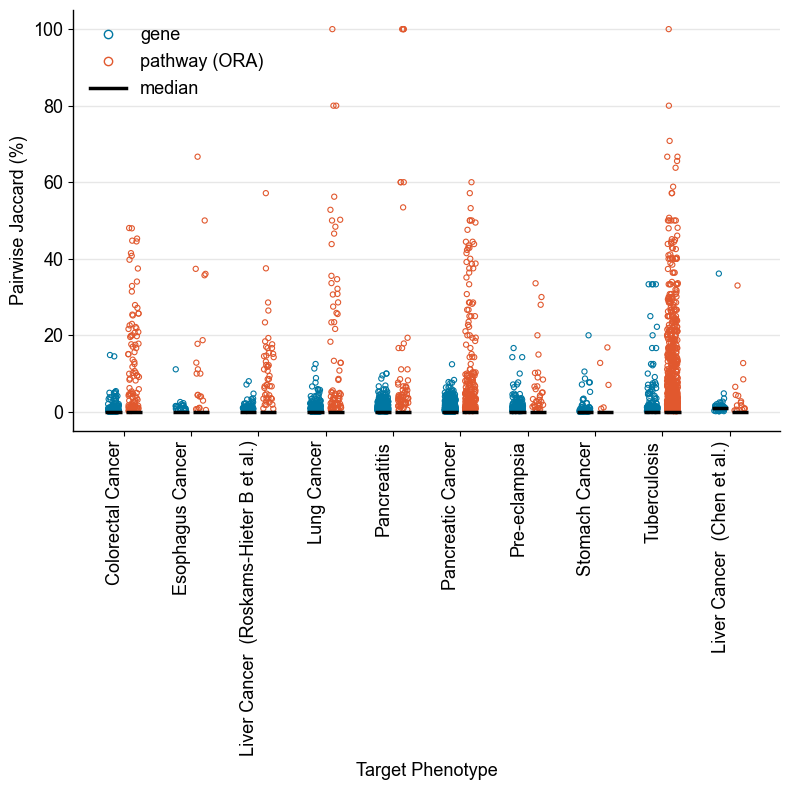

In [ ]:
# gene vs pathway(ORA) paired per phenotype, same x order (gene_jaccard_pct ascending).
# Phenotypes with >1 independent cohort (Liver Cancer: Chen et al. vs Roskams-Hieter B et al.)
# are plotted separately, not pooled.
import seaborn as sns

pheno_counts = summary.phenotype.value_counts()


def plot_label(row):
    if pheno_counts[row.phenotype] == 1:
        return row.phenotype
    m = re.search(r'\((.*?)\)', row.study_dir)
    return f'{row.phenotype} ({m.group(1).replace("_", " ")})' if m else row.study_dir


summary['plot_label'] = summary.apply(plot_label, axis=1)
study_to_label = dict(zip(summary.study_dir, summary.plot_label))

jacc_by_label, jacc_path_by_label = {}, {}
for pdir_name, label in study_to_label.items():
    rec = pickle.load(open(PCDIR / pdir_name / f'reoccurrence{q_tag(Q_MAIN)}.pkl', 'rb'))
    jacc_by_label[label] = (pairwise_overlap(rec['gene_sig'])[0] * 100).tolist()
    jacc_path_by_label[label] = (pairwise_overlap(rec['path_sig'])[0] * 100).tolist()

order_pair = summary.sort_values('gene_jaccard_pct').plot_label.tolist()
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8, 8))
colors = {'gene': "#0077A2", 'pathway (ORA)': "#E1582E"} 
offsets = {'gene': -0.15, 'pathway (ORA)': 0.15}
sources = {'gene': jacc_by_label, 'pathway (ORA)': jacc_path_by_label}

for level, src in sources.items():
    off, color = offsets[level], colors[level]
    for i, label in enumerate(order_pair):
        vals = np.array([v for v in src[label] if v > 0])
        x = i + off + rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(x, vals, facecolor='none', edgecolor=color, linewidth=0.8, s=14, zorder=3)
        med = np.median(src[label])
        ax.hlines(med, i + off - 0.12, i + off + 0.12, color='black', linewidth=2.5, zorder=4)

ax.set_xticks(range(len(order_pair)))
ax.set_xticklabels(order_pair, rotation=90, ha='right')
ax.set_xlabel('Target Phenotype')
ax.set_ylabel('Pairwise Jaccard (%)')
ax.grid(alpha=0.3, axis='y')
legend_handles = [plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor='none',
                              markeredgecolor=c, label=lvl) for lvl, c in colors.items()]
legend_handles.append(plt.Line2D([0], [0], color='black', linewidth=2.5, label='median'))
ax.legend(handles=legend_handles, frameon=False)
fig.tight_layout()
fig.savefig(PFDIR / f'gene_path_jaccard_paired_q{int(Q_MAIN*100)}.png')
plt.show()

In [53]:
# Split genes into group-significant (S, Stouffer's Z, q=0.05) vs group-non-significant (not-S),
# and compare their individual (per-patient) recurrence rate r_g directly -- Mann-Whitney U,
# one row per (phenotype, study).
from scipy.stats import mannwhitneyu

Q_GROUP = 0.05    # confirmatory tier, matches group_level_z_test's own convention
Q_INDIV = Q_MAIN  # per-patient BH-FDR, same threshold as the rest of this notebook

Z_all = np.load(ZDIR / 'Z_disease_shash.npy')
sm_all = pd.read_csv(ZDIR / 'sample_meta.csv')
sm_all['study'] = sm_all['batch'].str.replace(r'_Batch_\d+$', '', regex=True)
gene_names_all = pickle.load(open(ZDIR / 'gene_names.pkl', 'rb'))
N_genes = len(gene_names_all)
group_z_all = dc.stouffer_group_z(sm_all, Z_all, gene_names_all)


def recurrence_vs_group(pheno, study, gz):
    sub = sm_all[(sm_all.phenotype == pheno) & (sm_all.study == study) & sm_all.ood_keep]
    Zp = Z_all[sub.index.values]

    reject = np.zeros_like(Zp, dtype=bool)
    for i in range(Zp.shape[0]):
        f = np.isfinite(Zp[i])
        p = 2 * norm.sf(np.abs(Zp[i, f]))
        reject[i, f] = bh_fdr_reject(p, q=Q_INDIV)
    r_g = reject.mean(axis=0)

    gfinite = np.isfinite(gz)
    gp = 2 * norm.sf(np.abs(gz[gfinite]))
    greject = np.zeros(N_genes, dtype=bool)
    greject[gfinite] = bh_fdr_reject(gp, q=Q_GROUP)
    S_idx = np.where(greject & gfinite)[0]
    notS_idx = np.where(~greject & gfinite)[0]
    if len(S_idx) < 5 or len(notS_idx) < 5:
        return None

    _, pval = mannwhitneyu(r_g[S_idx], r_g[notS_idx], alternative='greater')
    return dict(phenotype=pheno, study=study, n_pat=Zp.shape[0], k=len(S_idx), k_notS=len(notS_idx),
                mean_rg_S=r_g[S_idx].mean(), mean_rg_notS=r_g[notS_idx].mean(), pval=pval)


rows = [recurrence_vs_group(pheno, study, gz) for (pheno, study), gz in group_z_all.items()]
recur_group_df = pd.DataFrame([r for r in rows if r is not None]).sort_values('pval')
recur_group_df['fold_enrichment'] = recur_group_df.mean_rg_S / recur_group_df.mean_rg_notS
display(recur_group_df.round(4))

,phenotype,study,n_pat,k,k_notS,mean_rg_S,mean_rg_notS,pval,fold_enrichment
2,Colorectal Cancer,Chen et al.,34,6595,13263,0.0251,0.0094,0.000,2.6797
7,ICI-treated Cancer,Raissadati et al.,9,5210,14648,0.0338,0.0013,0.000,26.0764
6,ICI-m,Raissadati et al.,10,5648,14210,0.1558,0.0252,0.000,6.1903
8,Liver Cancer,Chen et al.,10,2042,17816,0.1250,0.0441,0.000,2.8321
14,MM,Roskams-Hieter B et al.,17,2738,17120,0.0528,0.0143,0.000,3.6804
11,Lung Cancer,Chen et al.,26,5986,13872,0.0467,0.0183,0.000,2.5459
10,Liver Cirrhosis,Roskams-Hieter B et al.,4,222,19636,0.2117,0.0091,0.000,23.3877
4,HIV,Chang et al.,13,2118,17740,0.0577,0.0161,0.000,3.5867
13,MGUS,Roskams-Hieter B et al.,8,1422,18436,0.0419,0.0092,0.000,4.5539
16,Pancreatic Cancer,Moore et al.,72,4427,15431,0.0168,0.0088,0.000,1.9213
